In [1]:
from datasets import load_dataset

# https://huggingface.co/datasets/jxie/flickr8k
dataset = load_dataset("jxie/flickr8k")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})


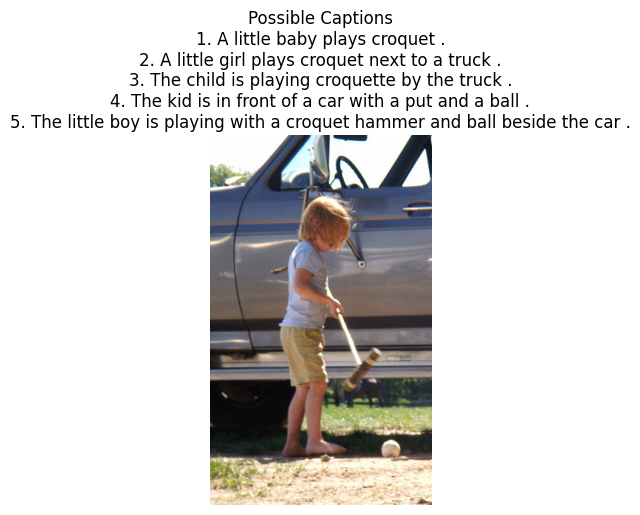

In [2]:
import matplotlib.pyplot as plt

# showing some possible caption and images
for i in range(1):
    sample = dataset["train"][1]
    captions = [sample["caption_0"], sample["caption_1"], sample["caption_2"], sample["caption_3"], sample["caption_4"]]
    plt.imshow(sample["image"])
    plt.axis("off")
    plt.title(f"Possible Captions{"\n"}{"\n".join(f"{i+1}. {c}" for i,c in enumerate(captions))}")
    plt.show()


In [3]:
# Load model
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification

processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = AutoModelForZeroShotImageClassification.from_pretrained("openai/clip-vit-base-patch32")

for i in range(1):
    sample = dataset["train"][1]
    captions = [sample["caption_0"], sample["caption_1"], sample["caption_2"], sample["caption_3"], sample["caption_4"]]
    inputs = processor(text=captions, images=sample["image"], return_tensors="pt", padding=True)
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)
    best_idx = probs.argmax(dim=1).item()
    print(captions[best_idx])



Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


The little boy is playing with a croquet hammer and ball beside the car .


In [4]:
# model parameters
total = sum(p.numel() for p in model.parameters())

print(f"Params | Total: {total/1e6:.2f}M | ")



Params | Total: 151.28M | 


In [5]:
from torch.utils.data import DataLoader
import torch

def transformFn(sample):
  images = [item["image"] for item in sample]
  captions = [[item["caption_0"],item["caption_1"],item["caption_2"],item["caption_3"],item["caption_4"]] for item in sample]

  return images, captions

testingData = dataset["test"]
testingDataLoader = DataLoader(testingData, batch_size=100, shuffle=False, collate_fn=transformFn)

model.eval()

recallAt1 = 0
recallAt3 = 0
recallAt5 = 0
total = 0
with torch.no_grad():
  for batchNum, batch in enumerate(testingDataLoader):
    print(f"Processing Batch {batchNum + 1}")
    images, captions = batch

    # flatten the captions
    flattenCaptions = []
    for i in range(len(captions)):
      flattenCaptions.extend(captions[i])

    inputs = processor(text=flattenCaptions, images=images, return_tensors="pt", padding=True)

    outputs = model(**inputs)

    logits_per_image = outputs.logits_per_image

    for i in range(len(images)):
      scores = logits_per_image[i]
      top1 = scores.argmax().item()
      top3 = scores.topk(3).indices.tolist()
      top5 = scores.topk(5).indices.tolist()


      getTrueCaptionIds= range(i*5, i*5 + 5)

      if top1 in getTrueCaptionIds:
        recallAt1 += 1

      if any(item in getTrueCaptionIds for item in top3):
        recallAt3 += 1

      if any(item in getTrueCaptionIds for item in top5):
        recallAt5 += 1



      total += 1

    # recall at each batch
    print(f"Recall@1: {recallAt1 / total * 100:.4f}")
    print(f"Recall@3: {recallAt3 / total * 100:.4f}")
    print(f"Recall@5: {recallAt5 / total * 100:.4f}")

print(f"{'=' * 50}")
print(f"Final Recall")
print(f"Recall@1: {recallAt1 / total * 100:.4f}")
print(f"Recall@3: {recallAt3 / total * 100:.4f}")
print(f"Recall@5: {recallAt5 / total * 100:.4f}")
print(f"{'=' * 50}")







Processing Batch 1
Recall@1: 91.0000
Recall@3: 100.0000
Recall@5: 100.0000
Processing Batch 2
Recall@1: 92.5000
Recall@3: 99.0000
Recall@5: 99.5000
Processing Batch 3
Recall@1: 91.6667
Recall@3: 98.6667
Recall@5: 99.6667
Processing Batch 4
Recall@1: 91.5000
Recall@3: 98.5000
Recall@5: 99.7500
Processing Batch 5
Recall@1: 91.6000
Recall@3: 98.8000
Recall@5: 99.8000
Processing Batch 6
Recall@1: 92.1667
Recall@3: 98.8333
Recall@5: 99.8333
Processing Batch 7
Recall@1: 92.7143
Recall@3: 98.7143
Recall@5: 99.8571
Processing Batch 8
Recall@1: 92.6250
Recall@3: 98.5000
Recall@5: 99.7500
Processing Batch 9
Recall@1: 93.0000
Recall@3: 98.5556
Recall@5: 99.7778
Processing Batch 10
Recall@1: 92.9000
Recall@3: 98.4000
Recall@5: 99.8000
Final Recall
Recall@1: 92.9000
Recall@3: 98.4000
Recall@5: 99.8000


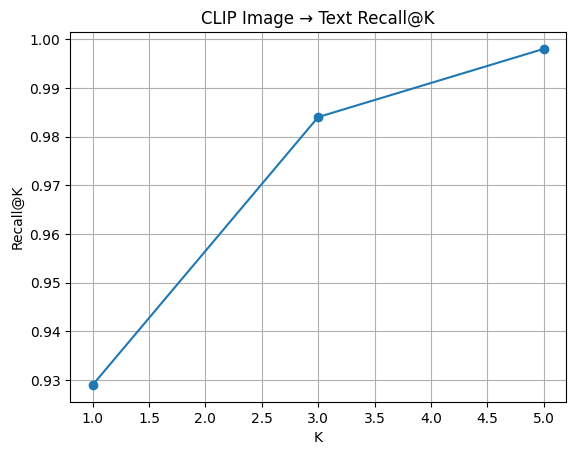

In [6]:
import matplotlib.pyplot as plt

Ks = [1, 3, 5]
recalls = [
    recallAt1 / total,
    recallAt3 / total,
    recallAt5 / total
]

plt.figure()
plt.plot(Ks, recalls, marker='o')
plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("CLIP Image → Text Recall@K")
plt.grid(True)
plt.show()


In [7]:
# playign with another
# https://huggingface.co/datasets/limenous/fashion_image_caption-100-v212

fashionDataset = load_dataset("limenous/fashion_image_caption-100-v212")
testingFashionDataset = fashionDataset["train"]


def transformFashionFn(sample):
  images = [item["image"] for item in sample]
  captions = [item["text"] for item in sample]

  return images, captions



fashionDatasetLoader = DataLoader(testingFashionDataset, batch_size=20, shuffle=False, collate_fn=transformFashionFn)

fashionRecallAt1 = 0
fashionRecallAt3 = 0
fashionRecallAt5 = 0

fashionTotal = 0

with torch.no_grad():
  for batchNum, batch in enumerate(fashionDatasetLoader):
    print(f"Processing Batch {batchNum + 1}")
    images, captions = batch
    inputs = processor(text=captions, images=images, return_tensors="pt", padding=True)

    outputs = model(**inputs)

    logits_per_image = outputs.logits_per_image

    for i in range(len(images)):
      scores = logits_per_image[i]
      top1 = scores.argmax().item()
      top3 = scores.topk(3).indices.tolist()
      top5 = scores.topk(5).indices.tolist()

      # true caption is the index
      trueCaptionId = i

      if top1 == trueCaptionId:
        fashionRecallAt1 += 1

      if trueCaptionId in top3:
        fashionRecallAt3 += 1

      if trueCaptionId in top5:
        fashionRecallAt5 += 1

      fashionTotal += 1

    print(f"Recall@1: {fashionRecallAt1 / fashionTotal * 100:.4f}")
    print(f"Recall@3: {fashionRecallAt3 / fashionTotal * 100:.4f}")
    print(f"Recall@5: {fashionRecallAt5 / fashionTotal * 100:.4f}")


print(f"{'=' * 50}")
print(f"Final Recall")
print(f"Recall@1: {fashionRecallAt1 / fashionTotal * 100:.4f}")
print(f"Recall@3: {fashionRecallAt3 / fashionTotal * 100:.4f}")
print(f"Recall@5: {fashionRecallAt5 / fashionTotal * 100:.4f}")
print(f"{'=' * 50}")












Processing Batch 1
Recall@1: 65.0000
Recall@3: 85.0000
Recall@5: 95.0000
Processing Batch 2
Recall@1: 72.5000
Recall@3: 87.5000
Recall@5: 95.0000
Processing Batch 3
Recall@1: 71.6667
Recall@3: 88.3333
Recall@5: 93.3333
Processing Batch 4
Recall@1: 75.0000
Recall@3: 90.0000
Recall@5: 95.0000
Processing Batch 5
Recall@1: 72.0000
Recall@3: 90.0000
Recall@5: 95.0000
Final Recall
Recall@1: 72.0000
Recall@3: 90.0000
Recall@5: 95.0000


In [8]:
def  evaluateModel(datasetPath, splitLabel, imageLabel, captionLabel, batchSize, maxRange = None ):
  fashionDataset = load_dataset(datasetPath)
  testingFashionDataset = fashionDataset[f"{splitLabel}"]

  if maxRange:
    testingFashionDataset = testingFashionDataset.select(range(maxRange))


  def transformFashionFn(sample):
    images = [item[f"{imageLabel}"] for item in sample]
    captions = [item[f"{captionLabel}"] for item in sample]

    return images, captions



  fashionDatasetLoader = DataLoader(testingFashionDataset, batch_size=batchSize, shuffle=False, collate_fn=transformFashionFn)

  fashionRecallAt1 = 0
  fashionRecallAt3 = 0
  fashionRecallAt5 = 0

  fashionTotal = 0

  model.eval()

  with torch.no_grad():
    for batchNum, batch in enumerate(fashionDatasetLoader):
      print(f"Processing Batch {batchNum + 1}")
      images, captions = batch
      inputs = processor(text=captions, images=images, return_tensors="pt", padding=True,truncation=True, max_length=77)

      outputs = model(**inputs)

      logits_per_image = outputs.logits_per_image

      for i in range(len(images)):
        scores = logits_per_image[i]
        top1 = scores.argmax().item()
        top3 = scores.topk(3).indices.tolist()
        top5 = scores.topk(5).indices.tolist()

        # true caption is the index
        trueCaptionId = i

        if top1 == trueCaptionId:
          fashionRecallAt1 += 1

        if trueCaptionId in top3:
          fashionRecallAt3 += 1

        if trueCaptionId in top5:
          fashionRecallAt5 += 1

        fashionTotal += 1

      print(f"Recall@1: {fashionRecallAt1 / fashionTotal * 100:.4f}")
      print(f"Recall@3: {fashionRecallAt3 / fashionTotal * 100:.4f}")
      print(f"Recall@5: {fashionRecallAt5 / fashionTotal * 100:.4f}")


  print(f"{'=' * 50}")
  print(f"Final Recall")
  print(f"Recall@1: {fashionRecallAt1 / fashionTotal * 100:.4f}")
  print(f"Recall@3: {fashionRecallAt3 / fashionTotal * 100:.4f}")
  print(f"Recall@5: {fashionRecallAt5 / fashionTotal * 100:.4f}")
  print(f"{'=' * 50}")

  Ks = [1, 3, 5]
  recalls = [
      fashionRecallAt1 / fashionTotal,
      fashionRecallAt3 / fashionTotal,
      fashionRecallAt5 / fashionTotal
  ]

  plt.figure()
  plt.plot(Ks, recalls, marker='o')
  plt.xlabel("K")
  plt.ylabel("Recall@K")
  plt.title(f"Model: {datasetPath}")
  plt.grid(True)
  plt.show()

Processing Batch 1
Recall@1: 65.0000
Recall@3: 85.0000
Recall@5: 95.0000
Processing Batch 2
Recall@1: 72.5000
Recall@3: 87.5000
Recall@5: 95.0000
Processing Batch 3
Recall@1: 71.6667
Recall@3: 88.3333
Recall@5: 93.3333
Processing Batch 4
Recall@1: 75.0000
Recall@3: 90.0000
Recall@5: 95.0000
Processing Batch 5
Recall@1: 72.0000
Recall@3: 90.0000
Recall@5: 95.0000
Final Recall
Recall@1: 72.0000
Recall@3: 90.0000
Recall@5: 95.0000


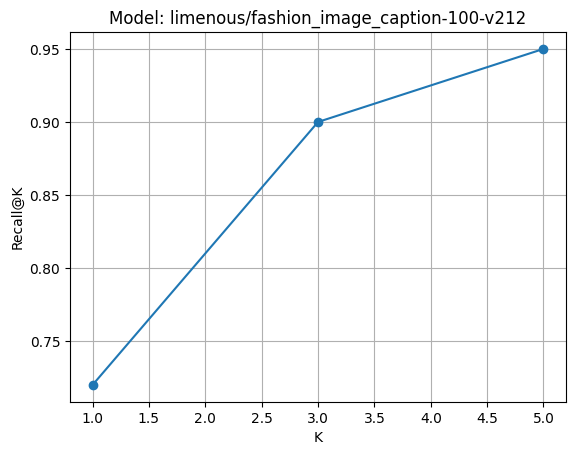

In [9]:
# https://huggingface.co/datasets/limenous/fashion_image_caption-100-v212
evaluateModel("limenous/fashion_image_caption-100-v212", "train", "image", "text", 20)

Processing Batch 1
Recall@1: 36.0000
Recall@3: 66.0000
Recall@5: 76.0000
Processing Batch 2
Recall@1: 40.0000
Recall@3: 66.0000
Recall@5: 74.0000
Processing Batch 3
Recall@1: 34.6667
Recall@3: 57.3333
Recall@5: 67.3333
Processing Batch 4
Recall@1: 37.5000
Recall@3: 60.0000
Recall@5: 69.5000
Processing Batch 5
Recall@1: 37.6000
Recall@3: 59.6000
Recall@5: 70.0000
Processing Batch 6
Recall@1: 38.3333
Recall@3: 61.0000
Recall@5: 70.6667
Processing Batch 7
Recall@1: 38.0000
Recall@3: 60.2857
Recall@5: 70.5714
Processing Batch 8
Recall@1: 36.5000
Recall@3: 59.0000
Recall@5: 70.7500
Processing Batch 9
Recall@1: 37.1111
Recall@3: 60.2222
Recall@5: 71.5556
Processing Batch 10
Recall@1: 38.0000
Recall@3: 61.2000
Recall@5: 72.6000
Processing Batch 11
Recall@1: 37.0909
Recall@3: 60.7273
Recall@5: 72.3636
Processing Batch 12
Recall@1: 36.6667
Recall@3: 59.5000
Recall@5: 71.3333
Processing Batch 13
Recall@1: 36.7692
Recall@3: 59.3846
Recall@5: 71.2308
Processing Batch 14
Recall@1: 36.1429
Recall@3:

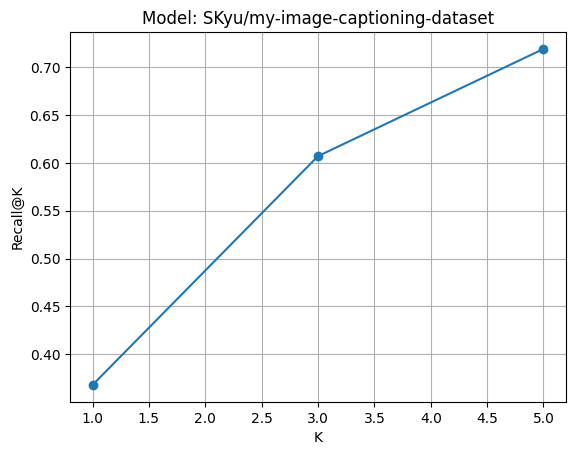

In [10]:
# https://huggingface.co/datasets/SKyu/my-image-captioning-dataset
evaluateModel("SKyu/my-image-captioning-dataset", "train", "image", "prompt", 50, 1000)

In [11]:
import torch.nn.functional as F

# lets do the fine tuning here 
# first select the dataset and divide it for the training, testing and validation
# https://huggingface.co/datasets/SKyu/my-image-captioning-dataset

# load the dataset
dataset = load_dataset("SKyu/my-image-captioning-dataset")

# divide the dataset for the training, testing and validation
test_dataset = dataset["train"].select(range(1000))
train_dataset = dataset["train"].select(range(1000, 2000))
validation_dataset = dataset["train"].select(range(2000, 3000))


# we already have the processor and model from previous blocks
# processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
# model = AutoModelForZeroShotImageClassification.from_pretrained("openai/clip-vit-base-patch32")


model.train()


def transofrmTrainingFn(sample):
  images = [item["image"] for item in sample]
  captions = [item["prompt"] for item in sample]

  return images, captions

trainingDataLoader = DataLoader(train_dataset, batch_size=50, shuffle=True, collate_fn=transofrmTrainingFn)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-6)

numEpochs = 5

for epoch in range(numEpochs):
  for batchNum, batch in enumerate(trainingDataLoader):
    print(f"Processing Batch {batchNum + 1}")
    images, captions = batch

    inputs = processor(text=captions, images=images, return_tensors="pt", padding=True,truncation=True, max_length=77)

    outputs = model(**inputs)

    logits_per_image = outputs.logits_per_image
    logits_per_text = outputs.logits_per_text

    batch_size = logits_per_image.size(0)
    labels = torch.arange(batch_size)
    
    loss_i = F.cross_entropy(logits_per_image, labels)
    loss_t = F.cross_entropy(logits_per_text, labels)

    loss = (loss_i + loss_t) / 2

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    print(f"Epoch {epoch + 1}, Batch {batchNum + 1}, Loss: {loss.item()}")






Processing Batch 1
Epoch 1, Batch 1, Loss: 2.233652353286743
Processing Batch 2
Epoch 1, Batch 2, Loss: 1.4589660167694092
Processing Batch 3
Epoch 1, Batch 3, Loss: 1.3613064289093018
Processing Batch 4
Epoch 1, Batch 4, Loss: 1.4017813205718994
Processing Batch 5
Epoch 1, Batch 5, Loss: 0.942037045955658
Processing Batch 6
Epoch 1, Batch 6, Loss: 0.7569290399551392
Processing Batch 7
Epoch 1, Batch 7, Loss: 0.9474440813064575
Processing Batch 8
Epoch 1, Batch 8, Loss: 1.229634404182434
Processing Batch 9
Epoch 1, Batch 9, Loss: 0.9581098556518555
Processing Batch 10
Epoch 1, Batch 10, Loss: 1.2015070915222168
Processing Batch 11
Epoch 1, Batch 11, Loss: 0.9841246604919434
Processing Batch 12
Epoch 1, Batch 12, Loss: 1.0793683528900146
Processing Batch 13
Epoch 1, Batch 13, Loss: 1.0478484630584717
Processing Batch 14
Epoch 1, Batch 14, Loss: 0.8220349550247192
Processing Batch 15
Epoch 1, Batch 15, Loss: 0.8427599668502808
Processing Batch 16
Epoch 1, Batch 16, Loss: 1.25414228439331

Processing Batch 1
Recall@1: 60.0000
Recall@3: 82.0000
Recall@5: 88.0000
Processing Batch 2
Recall@1: 62.0000
Recall@3: 87.0000
Recall@5: 91.0000
Processing Batch 3
Recall@1: 52.6667
Recall@3: 76.6667
Recall@5: 84.0000
Processing Batch 4
Recall@1: 57.0000
Recall@3: 79.5000
Recall@5: 87.0000
Processing Batch 5
Recall@1: 58.8000
Recall@3: 82.4000
Recall@5: 89.6000
Processing Batch 6
Recall@1: 61.3333
Recall@3: 83.6667
Recall@5: 90.6667
Processing Batch 7
Recall@1: 62.0000
Recall@3: 84.2857
Recall@5: 91.4286
Processing Batch 8
Recall@1: 60.2500
Recall@3: 84.2500
Recall@5: 91.7500
Processing Batch 9
Recall@1: 61.5556
Recall@3: 84.6667
Recall@5: 92.0000
Processing Batch 10
Recall@1: 61.8000
Recall@3: 85.4000
Recall@5: 92.4000
Processing Batch 11
Recall@1: 61.4545
Recall@3: 85.2727
Recall@5: 92.3636
Processing Batch 12
Recall@1: 60.8333
Recall@3: 84.5000
Recall@5: 91.8333
Processing Batch 13
Recall@1: 61.5385
Recall@3: 85.2308
Recall@5: 92.3077
Processing Batch 14
Recall@1: 61.2857
Recall@3:

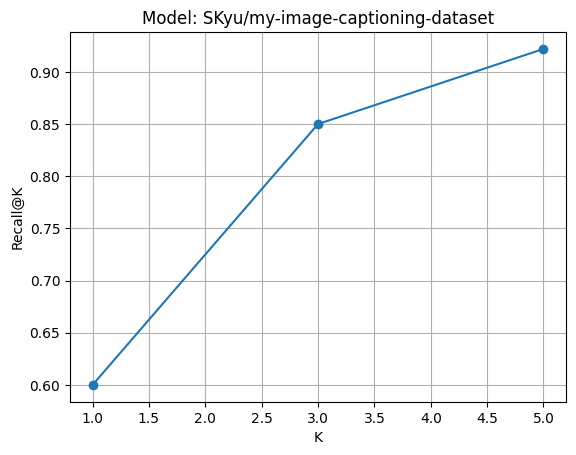

In [12]:
# https://huggingface.co/datasets/SKyu/my-image-captioning-dataset
evaluateModel("SKyu/my-image-captioning-dataset", "train", "image", "prompt", 50, 1000)